# Comprehensive Analysis of Energy Distance

## Table of Contents
1. [Definition and Intuitive Explanation](#1-definition-and-intuitive-explanation)  
2. [Mathematical Properties and Formula Derivation](#2-mathematical-properties-and-formula-derivation)  
3. [Steps for Statistical Testing](#3-steps-for-statistical-testing)  
4. [Optimization Strategies for High-Dimensional Data](#4-optimization-strategies-for-high-dimensional-data)  
5. [Weighted Adjustment for Unequal Sample Sizes](#5-weighted-adjustment-for-unequal-sample-sizes)  
6. [Comparison with Other Methods](#6-comparison-with-other-methods)  
7. [Application Scenarios and Examples](#7-application-scenarios-and-examples)  
8. [References and Tools](#8-references-and-tools)  

---

### 1. Definition and Intuitive Explanation
**Energy Distance** is a non-parametric statistic that measures the discrepancy between two probability distributions $ P $ and $ Q $. It is defined as:  
$$
\mathcal{E}(P, Q) = 2 \, \mathbb{E} \|X - Y\| - \mathbb{E} \|X - X'\| - \mathbb{E} \|Y - Y'\|
$$
- **Intuition**:  
  - $ 2\mathbb{E}\|X - Y\| $: Twice the average distance between samples from the two distributions.  
  - $ \mathbb{E}\|X - X'\| $ and $ \mathbb{E}\|Y - Y'\| $: Average distances within each distribution.  
- **Key Property**: $ \mathcal{E}(P, Q) = 0 $ if and only if $ P = Q $; otherwise, $ \mathcal{E} > 0 $.

---

### 2. Mathematical Properties and Formula Derivation
1. **Non-Negativity**: $ \mathcal{E}(P, Q) \geq 0 $, with equality iff $ P = Q $.  
2. **Symmetry**: $ \mathcal{E}(P, Q) = \mathcal{E}(Q, P) $.  
3. **Triangle Inequality**: $ \mathcal{E}(P, Q) \leq \mathcal{E}(P, R) + \mathcal{E}(R, Q) $.  

**Characteristic Function Perspective**:  
$$
\mathcal{E}(P, Q) = \int_{\mathbb{R}^d} \frac{|\phi_P(t) - \phi_Q(t)|^2}{\|t\|^{d+1}} dt
$$
where $ \phi_P $ and $ \phi_Q $ are the characteristic functions of $ P $ and $ Q $.

---

### 3. Steps for Statistical Testing
1. **Data Preparation**: Standardize datasets $ X \in \mathbb{R}^{n \times d} $ and $ Y \in \mathbb{R}^{m \times d} $.  
2. **Compute Sample Energy Distance**:  
   $$
   \hat{\mathcal{E}} = \frac{2}{nm} \sum_{i,j} \|x_i - y_j\| - \frac{1}{n^2} \sum_{i,j} \|x_i - x_j\| - \frac{1}{m^2} \sum_{i,j} \|y_i - y_j\|
   $$
3. **Significance Testing**:  
   - **Permutation Test**: Merge and randomly split data to generate a null distribution.  
   - **Asymptotic Theory**: Use chi-square distribution for large samples.  
4. **Conclusion**: Reject $ H_0: P = Q $ if $ p\text{-value} < 0.05 $.

---

### 4. Optimization Strategies for High-Dimensional Data
- **Dimensionality Reduction**: Apply PCA/t-SNE to retain principal components.  
- **Blockwise Computation**: Process high-dimensional matrices in blocks.  
- **Sparsity Assumption**: Focus on critical dimensions.  
- **Computational Optimization**:  
  - Random approximation (e.g., Monte Carlo).  
  - GPU/distributed computing acceleration.  

---

In [72]:
import numpy as np
from scipy.spatial import distance_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def weighted_energy_distance(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)
    n, m = X.shape[0], Y.shape[0]
    
    cross_sum = distance_matrix(X, Y).sum()
    cross_term = (2 / (n * m)) * cross_sum
    
    def calc_internal(Z):
        size = len(Z)
        if size <= 1:
            return 0.0
        dist = distance_matrix(Z, Z)
        np.fill_diagonal(dist, 0)
        return dist.sum() / (size * (size - 1))
    
    internal_X = calc_internal(X)
    internal_Y = calc_internal(Y)
    
    energy = cross_term - internal_X - internal_Y
    return max(energy, 0)

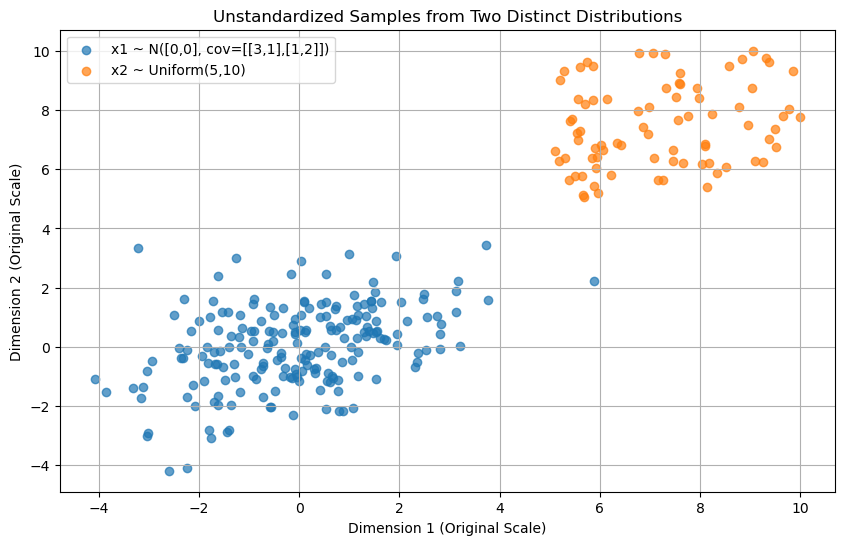

In [73]:


# 生成原始数据（未标准化）
np.random.seed(42)

# 定义样本量
n1, n2 = 200, 80


mean1 = [0, 0]
cov1 = [[3, 1], [1, 2]]
x1 = np.random.multivariate_normal(mean1, cov1, n1)


low, high = 5, 10
x2 = np.random.uniform(low, high, (n2, 2))


plt.figure(figsize=(10, 6))
plt.scatter(x1[:, 0], x1[:, 1], alpha=0.7, label='x1 ~ N([0,0], cov=[[3,1],[1,2]])')
plt.scatter(x2[:, 0], x2[:, 1], alpha=0.7, label='x2 ~ Uniform(5,10)')
plt.xlabel("Dimension 1 (Original Scale)")
plt.ylabel("Dimension 2 (Original Scale)")
plt.title("Unstandardized Samples from Two Distinct Distributions")
plt.legend()
plt.grid(True)
plt.show()

scaler_x1 = StandardScaler().fit(x1)
scaler_x2 = StandardScaler().fit(x2)
x1_scaled = scaler_x1.transform(x1)
x2_scaled = scaler_x2.transform(x2)


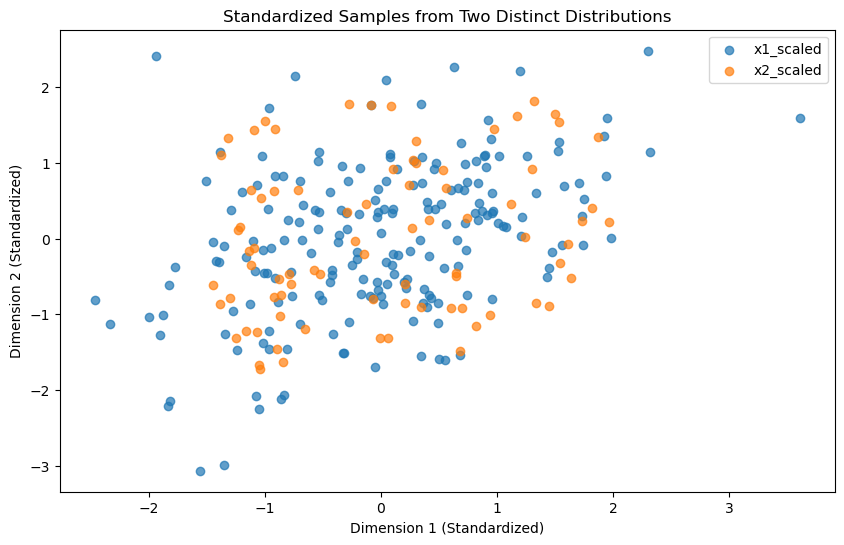

In [74]:
plt.figure(figsize=(10, 6))
plt.scatter(x1_scaled[:, 0], x1_scaled[:, 1], alpha=0.7, label='x1_scaled')
plt.scatter(x2_scaled[:, 0], x2_scaled[:, 1], alpha=0.7, label='x2_scaled')
plt.xlabel("Dimension 1 (Standardized)")
plt.ylabel("Dimension 2 (Standardized)")
plt.title("Standardized Samples from Two Distinct Distributions")
plt.legend()
plt.show()

In [75]:
original_statistic = weighted_energy_distance(x1, x2)
print(f"Original statistic: {original_statistic:.4f}")

Original statistic: 15.7849


In [76]:
standardized_statistic = weighted_energy_distance(x1_scaled, x2_scaled)
print(f"Standardized statistic: {standardized_statistic:.4f}")

Standardized statistic: 0.0000
